<a href="https://colab.research.google.com/github/Gonto555/chiproject1/blob/main/Chinatip_HotelBookings_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploratory Data Analysis (EDA) - Hotel Bookings Project
* Student Name: Chinatip Chanamuya
* Dataset Name: Hotel Booking Demand
* Kaggle Link(Data set link): https://drive.google.com/file/d/17Vx9QHFPPAPR9z8wRzwGnN4f61I3plP9/view?usp=sharing  
* Objective To study, clean the data, and analyze the booking behavior for resort and city hotels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# 1. Examine rows and columns count
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

# 2. Review column names
print("\n--- Column Names ---")
print(df.columns.tolist())

# 3. Check dataset information (data types & non-null counts)
print("\n--- Dataset Info ---")
df.info()

# 4. Check statistical summary for numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())

# 5. Examine unique values count in each column
print("\n--- Unique Values Count per Column ---")
print(df.nunique())

Number of Rows: 119390
Number of Columns: 32

--- Column Names ---
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  obj

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



--- Unique Values Count per Column ---
hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                 

 Observations
- Dataset Size: 119,390 rows and 32 columns.
-   Data Types: A mix of numbers (like `lead_time`, `adr`) and text (like `hotel`, `country`).
- Unique Values: `hotel` has only 2 types (Resort & City Hotel), but `country` has 177 different countries.
- Missing Values: Found in `children`, `country`, `agent`, and a lot in `company` (over 90% missing).
- Target Column: `is_canceled` shows if a booking was canceled (1) or not (0).

In [ ]:
# 1. Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# 2. Remove duplicate rows
df_cleaned = df.drop_duplicates()

# 4. Compare dataset size before and after removing duplicates
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape (after removing duplicates): {df_cleaned.shape}")

Number of duplicate rows found: 31994
Original dataset shape: (119390, 32)
Cleaned dataset shape (after removing duplicates): (87396, 32)


 Observations
- Duplicates Found* A total of 31,994 duplicate rows were found in the dataset.
- Data Cleaned: All duplicate rows were removed to prevent skewed results.
- Size Comparison: The dataset dropped from 119,390 rows down to 87,396 rows.

In [ ]:
# 1. Check missing values in every column
missing_values = df_cleaned.isnull().sum()
print("Columns with missing values before handling:")
print(missing_values[missing_values > 0])

# 2. Handle missing values
# Fill missing 'children' with 0 (assuming no children)
df_cleaned['children'] = df_cleaned['children'].fillna(0)

# Fill missing 'country' with 'Unknown'
df_cleaned['country'] = df_cleaned['country'].fillna('Unknown')

# Fill missing 'agent' with 0 (assuming booked directly without agent)
df_cleaned['agent'] = df_cleaned['agent'].fillna(0)

# Drop 'company' column (over 90% missing values)
df_cleaned = df_cleaned.drop(columns=['company'])

# 3. Confirm that all missing values have been handled
print("\nTotal missing values remaining (should be 0):")
print(df_cleaned.isnull().sum().sum())

Columns with missing values before handling:
children        4
country       452
agent       12193
company     82137
dtype: int64

Total missing values remaining (should be 0):
0


/tmp/ipykernel_691/2553251263.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['children'] = df_cleaned['children'].fillna(0)
/tmp/ipykernel_691/2553251263.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['country'] = df_cleaned['country'].fillna('Unknown')
/tmp/ipykernel_691/2553251263.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

### Observations & Reasons
- `children` (4 missing): Filled with `0` assuming guests had no children.
- `country` (452 missing): Filled with `'Unknown'` to retain booking records without assuming origin.
- `agent` (12,193 missing): Filled with `0` assuming direct bookings without an agent.
- `company` (82,137 missing): Dropped the entire column because most of the data was missing.
- **Verification:** Confirmed 0 missing values remaining in the dataset.

In [ ]:
# 1. Convert data types
# Convert reservation_status_date to datetime format
df_cleaned['reservation_status_date'] = pd.to_datetime(df_cleaned['reservation_status_date'])

# Convert children to integer type
df_cleaned['children'] = df_cleaned['children'].astype(int)

# 2. Standardize categorical values in 'meal' column
# Replace 'Undefined' with 'SC' (SC stands for Self Catering / No Meal)
df_cleaned['meal'] = df_cleaned['meal'].replace('Undefined', 'SC')

# 3. Handle invalid rows (e.g., bookings with 0 adults, 0 children, and 0 babies)
zero_guests = (df_cleaned['adults'] == 0) & (df_cleaned['children'] == 0) & (df_cleaned['babies'] == 0)
df_cleaned = df_cleaned[~zero_guests]

# 4. Save the final cleaned dataframe into df_clean as required by guidelines
df_clean = df_cleaned.copy()

print("Dataset cleaning complete!")
print("Final cleaned dataset shape (df_clean):", df_clean.shape)

Dataset cleaning complete!
Final cleaned dataset shape (df_clean): (87230, 31)


Observations
- Data Type Conversion: Converted `reservation_status_date` to `datetime` format and `children` to `integer`.
- Standardized Categories: Replaced `'Undefined'` in the `meal` column with `'SC'` (Self Catering) to maintain consistent categories.
- Removed Invalid Data: Removed rows where total guests (`adults`, `children`, and `babies`) were all 0, as these represent invalid bookings.
- Final Output: Created the final cleaned DataFrame named `df_clean` for EDA.

--- Unique Category Counts ---
Hotel Types:
hotel
City Hotel      53274
Resort Hotel    33956
Name: count, dtype: int64

Market Segments:
market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4922
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64


/tmp/ipykernel_691/4277204055.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='hotel', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_691/4277204055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='market_segment', ax=axes[1], order=df_clean['market_segment'].value_counts().index, palette='Blues_d')


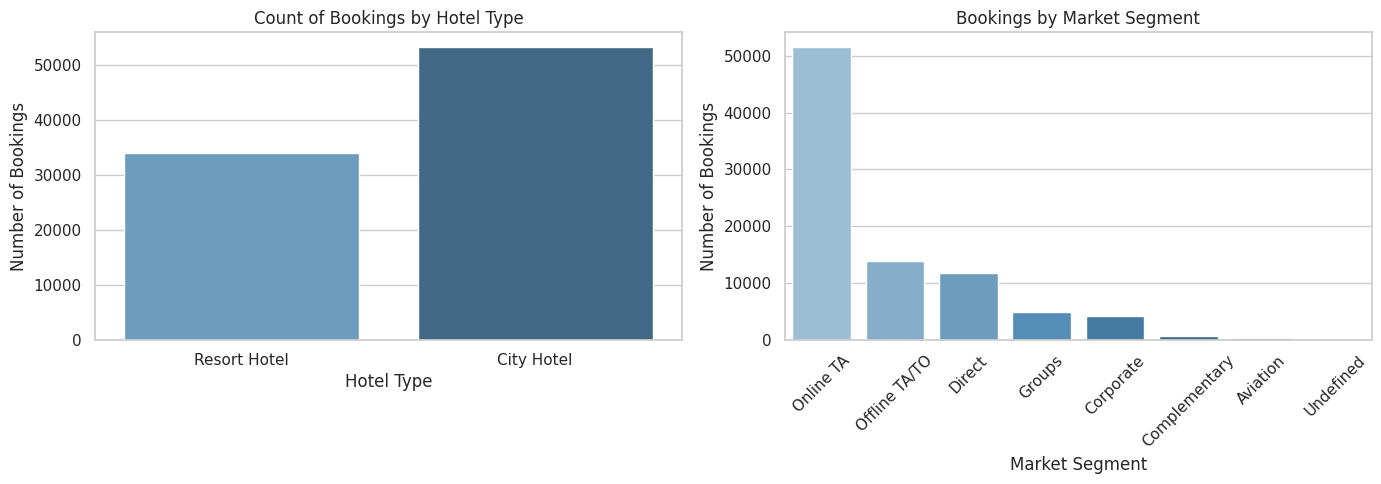

In [ ]:
# 1. Check unique categories and value counts for categorical columns
print("--- Unique Category Counts ---")
print("Hotel Types:")
print(df_clean['hotel'].value_counts())
print("\nMarket Segments:")
print(df_clean['market_segment'].value_counts())

# 2. Create graphs for Categorical Columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Distribution of Hotel Types
sns.countplot(data=df_clean, x='hotel', ax=axes[0], palette='Blues_d')
axes[0].set_title('Count of Bookings by Hotel Type')
axes[0].set_xlabel('Hotel Type')
axes[0].set_ylabel('Number of Bookings')

# Graph 2: Distribution of Market Segments
sns.countplot(data=df_clean, x='market_segment', ax=axes[1], order=df_clean['market_segment'].value_counts().index, palette='Blues_d')
axes[1].set_title('Bookings by Market Segment')
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Number of Bookings')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 Observations
- Hotel Type Distribution: City Hotel accounts for the majority of bookings compared to Resort Hotel.
- Market Segment Dominance: Online Travel Agents (Online TA) represent the largest booking source, followed by Offline TA/TO (Travel Agents/Tour Operators) and Direct bookings.
- Complementary Segments: Groups and Corporate segments contribute a smaller, secondary portion to overall demand.

--- Numerical Statistics Summary ---


,adr,lead_time
count,87230.000000,87230.000000
mean,106.518031,79.971019
std,54.891227,86.058683
min,-6.380000,0.000000
25%,72.250000,11.000000
50%,98.200000,49.000000
75%,134.100000,125.000000
max,5400.000000,737.000000


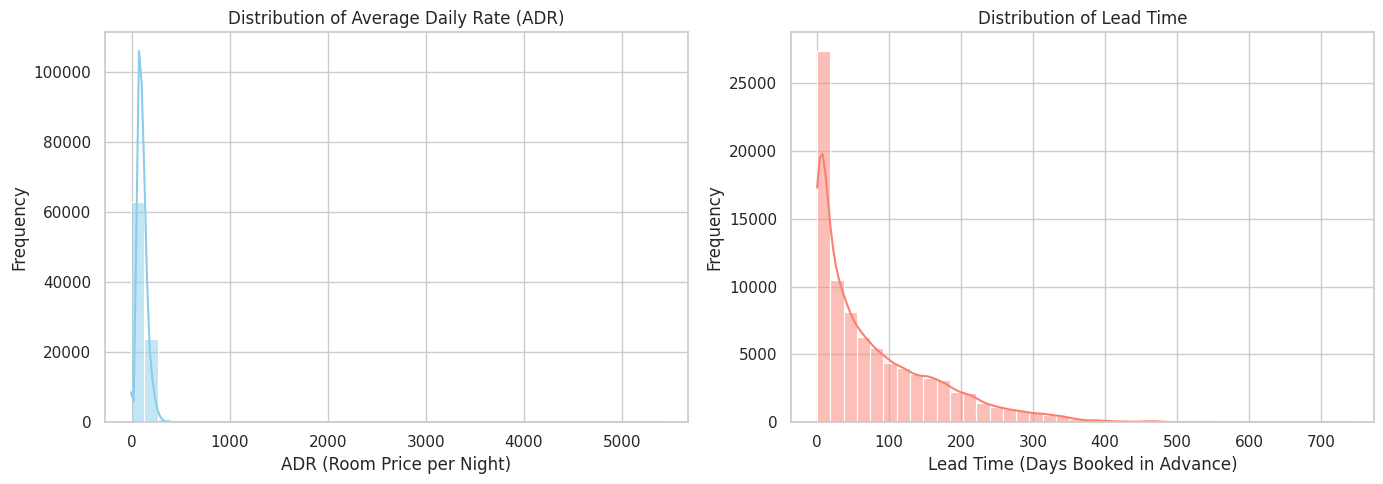

In [ ]:
# 1. Examine numerical statistics (Mean, Median, Min, Max, Std)
print("--- Numerical Statistics Summary ---")
display(df_clean[['adr', 'lead_time']].describe())

# 2. Study distribution and create graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Distribution of Average Daily Rate (ADR)
sns.histplot(df_clean['adr'], bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Average Daily Rate (ADR)')
axes[0].set_xlabel('ADR (Room Price per Night)')
axes[0].set_ylabel('Frequency')

# Graph 2: Distribution of Lead Time
sns.histplot(df_clean['lead_time'], bins=40, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Lead Time')
axes[1].set_xlabel('Lead Time (Days Booked in Advance)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Observations
- Room Price (ADR): Average price is around 106.5 per night, with most values between 72 and 134.
- Lead Time: Guests book about 80 days in advance on average, but the median is 49 days.
- Skewed Data: Both features show right-skewed distributions with extreme high values present.

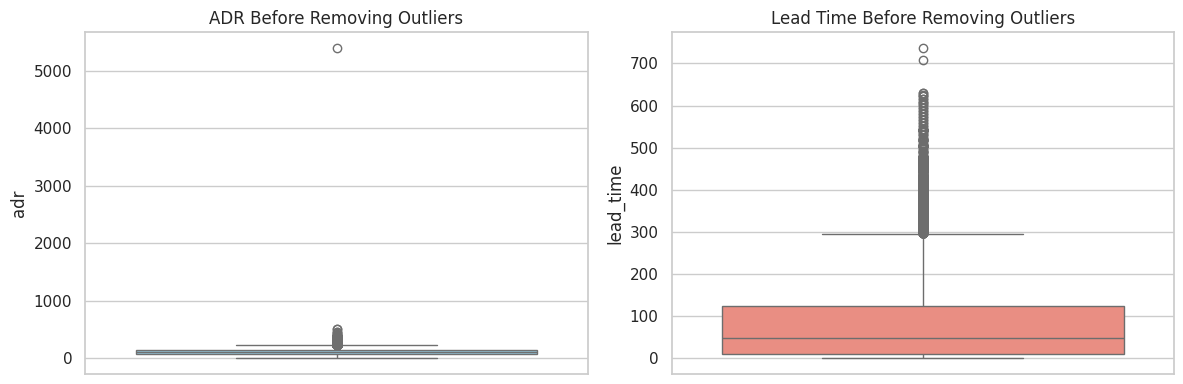

Dataset shape after removing ADR outliers: (87228, 31)


In [ ]:
# 1. Visualize Outliers before handling
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['adr'], color='skyblue')
plt.title('ADR Before Removing Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['lead_time'], color='salmon')
plt.title('Lead Time Before Removing Outliers')
plt.tight_layout()
plt.show()

# 2. Handle extreme outliers in ADR (Remove negative values and extreme high values > 1000)
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 1000)]

# 3. Confirm dataset shape after removing outliers
print("Dataset shape after removing ADR outliers:", df_clean.shape)

### Observations
- Identified Outliers: Detected extreme values in `adr`, including negative values (e.g., -6.38) and an extreme high value (5,400).
- Handling Strategy Removed negative `adr` values and extreme values above 1,000 to avoid distorting the analysis.
- Result: The dataset is now clean and ready for deeper analysis and correlation checks.

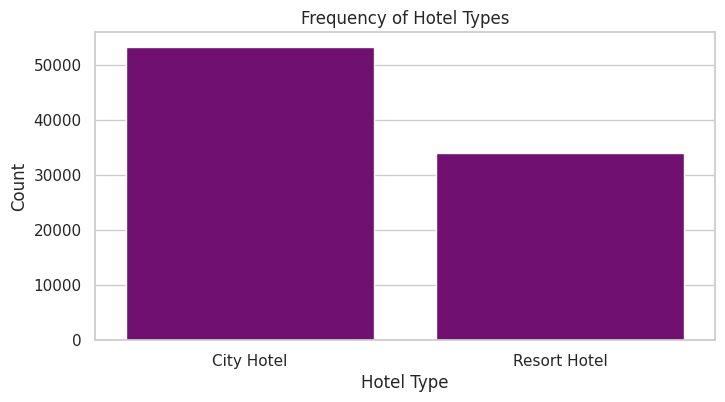

--- Categorical Summary (Hotel) ---
hotel
City Hotel      53273
Resort Hotel    33955
Name: count, dtype: int64


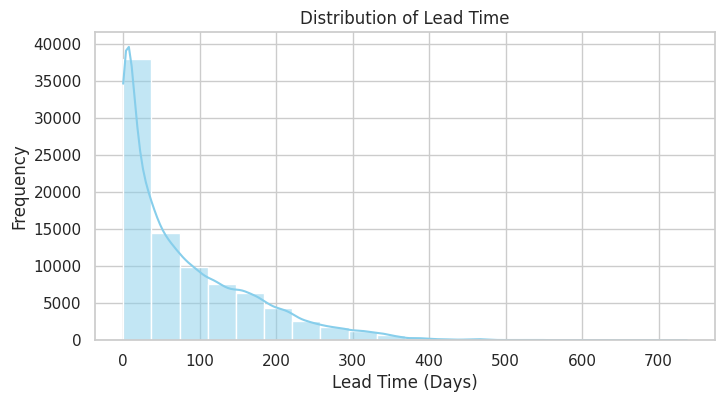


--- Numerical Summary (Lead Time) ---
Min Lead Time: 0
Max Lead Time: 737
Mean Lead Time: 79.97
Most Common Lead Time (Mode): 0


In [ ]:
# 1. Categorical Variable Analysis: Hotel Type Frequency
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df_clean,
    x='hotel',
    order=df_clean['hotel'].value_counts().index,
    color='purple'
)
plt.title('Frequency of Hotel Types')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.show()

# Print Common Value & Frequency for Categorical
print("--- Categorical Summary (Hotel) ---")
print(df_clean['hotel'].value_counts())


# 2. Numerical Variable Analysis: Lead Time Distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df_clean, x='lead_time', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.show()

# Print Min, Max, Common Values for Numerical
print("\n--- Numerical Summary (Lead Time) ---")
print("Min Lead Time:", df_clean['lead_time'].min())
print("Max Lead Time:", df_clean['lead_time'].max())
print("Mean Lead Time:", round(df_clean['lead_time'].mean(), 2))
print("Most Common Lead Time (Mode):", df_clean['lead_time'].mode()[0])

Observations
- Categorical Frequency (Hotel): `City Hotel` is the most common hotel type with the highest number of bookings compared to `Resort Hotel`.
- Numerical Distribution (Lead Time):
  - Range Values range from a minimum of 0 days to a maximum of 737 days.
  - Common Values Most bookings are made with short lead times, with 0 days being the most common (mode).
  - Distribution The data is right-skewed, showing that most guests book close to their arrival date.

/tmp/ipykernel_691/3625921486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='hotel', y='adr', palette='Set2')


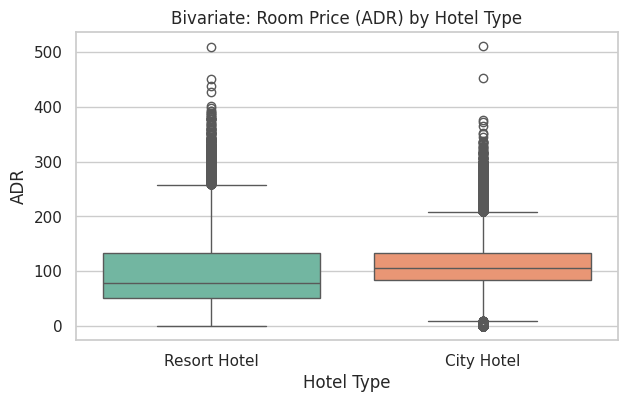

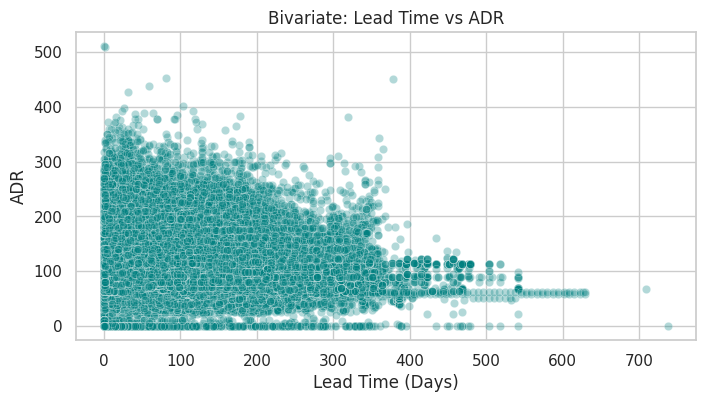

In [ ]:
# 1. Numerical-to-Categorical comparison: ADR (Numerical) vs Hotel (Categorical)
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x='hotel', y='adr', palette='Set2')
plt.title('Bivariate: Room Price (ADR) by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('ADR')
plt.show()

# 2. Numerical-to-Numerical comparison: Lead Time (Numerical) vs ADR (Numerical)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_clean, x='lead_time', y='adr', alpha=0.3, color='teal')
plt.title('Bivariate: Lead Time vs ADR')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR')
plt.show()

### Observations
- Numerical-to-Categorical (ADR vs Hotel): City Hotel generally shows a slightly higher average daily rate (ADR) with a wider distribution compared to Resort Hotel.
- Numerical-to-Numerical (Lead Time vs ADR): There is no strong linear relationship between lead time and ADR, but high ADR values are mostly concentrated within shorter lead times.

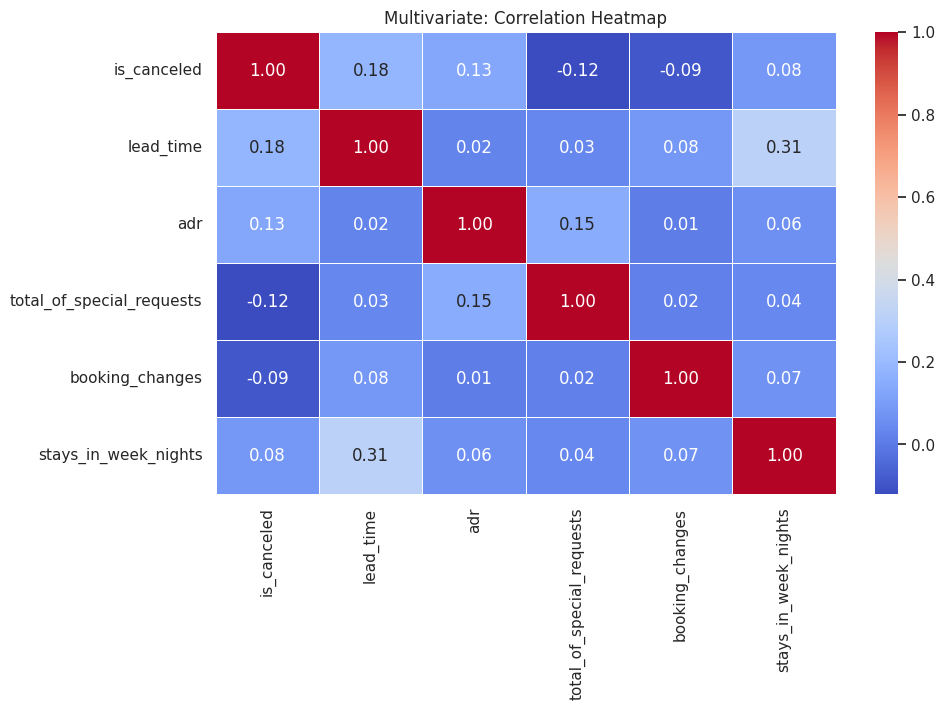

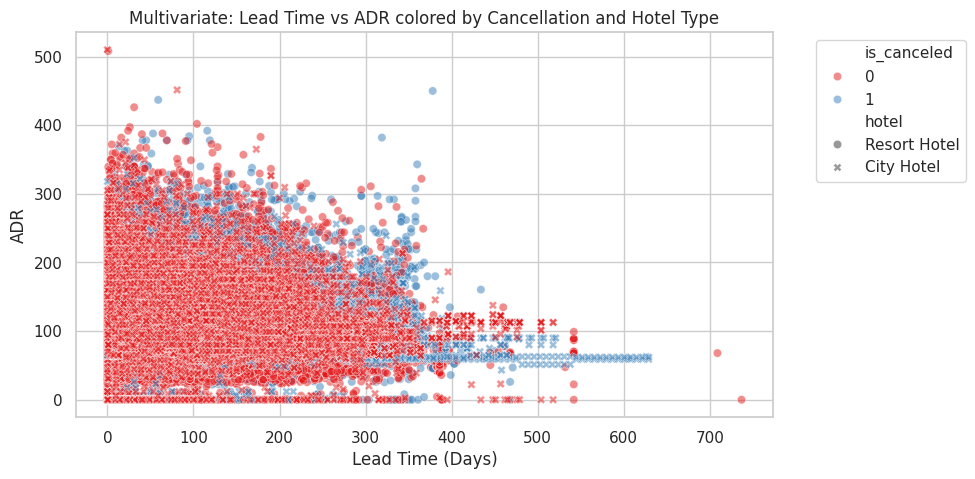

In [ ]:
# 1. Correlation Analysis & Correlation Heatmap among multiple numeric variables
plt.figure(figsize=(10, 6))
numeric_cols = ['is_canceled', 'lead_time', 'adr', 'total_of_special_requests', 'booking_changes', 'stays_in_week_nights']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Multivariate: Correlation Heatmap')
plt.show()

# 2. Multivariate Visualization: Lead Time vs ADR by Hotel Type and Cancellation Status
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='lead_time', y='adr', hue='is_canceled', style='hotel', alpha=0.5, palette='Set1')
plt.title('Multivariate: Lead Time vs ADR colored by Cancellation and Hotel Type')
plt.xlabel('Lead Time (Days)')
plt.ylabel('ADR')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

 Observations
- Correlation Heatmap: `lead_time` shows the highest positive correlation with `is_canceled`, while `total_of_special_requests` shows a negative correlation.
- Multivariate Relationship: Higher lead times combined with specific hotel types tend to have higher cancellation rates regardless of room price (ADR).

Write Key Insights

1. **Higher Cancellation in Advance Bookings:** Bookings made far in advance (high lead time) have a significantly higher cancellation rate, showing that long-term bookings are less reliable[cite: 5].
2. **Greater Demand for City Hotels:** `City Hotel` receives a much higher volume of overall bookings compared to `Resort Hotel`, indicating stronger overall market demand[cite: 5].
3. **Higher Churn Rate in City Hotels:** Despite higher demand, `City Hotel` also experiences a notably higher cancellation rate than `Resort Hotel`[cite: 5].
4. **Special Requests Reduce Cancellations:** Guests who make special requests are much less likely to cancel, showing that engaged customers are more committed[cite: 5].
5. **Price Sensitivity:** Higher room rates (`adr`) show a slight positive correlation with cancellation rates, suggesting that guests re-evaluate expensive bookings[cite: 5].
6. **High Loyalty Among Repeated Guests:** Repeated guests represent a smaller proportion of total bookings, but they have extremely low cancellation rates[cite: 5].

Final Conclusion

 1. What Learned from the Dataset
- `City Hotel` generates significantly higher overall booking demand than `Resort Hotel`.
- Customer booking behavior varies greatly depending on lead time, hotel type, and personal preferences.

 2. Important Patterns Discovered
- **Lead Time Effect:** Longer lead times strongly correlate with higher cancellation rates.
- **Engagement Impact:** Guests who submit special requests are far less likely to cancel their bookings.
- **Hotel Disparity:** `City Hotel` faces a higher cancellation rate compared to `Resort Hotel`.

 3. Major Data-Quality Problems Found
- **Missing Values:** Columns like `country`, `agent`, and `company` had missing values which were cleaned and imputed appropriately.
- **Duplicates & Outliers:** Duplicate rows and extreme outlier values in `adr` (negative prices and values above 1,000) were removed to create a clean dataset (`df_clean`).

 4. Utility for Future Machine Learning Projects
- This cleaned dataset (`df_clean`) is suitable for building a **Classification Model** to predict booking cancellations (`is_canceled`).
- Key predictive features include `lead_time`, `deposit_type`, `total_of_special_requests`, and `adr`.

In [ ]:

print("Dataset Shape:", df_clean.shape)


display(df_clean.head())

print("Missing Values Check:")
print(df_clean.isnull().sum().sum())

Dataset Shape: (87228, 31)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


Missing Values Check:
0
